# TimeGAN v4 — Fix de saturación de sigmoid

## Diagnóstico definitivo de v3

El embedder nunca bajó de 0.064 en 500 épocas. Con `feature_dim=23` y MinMaxScaler,
esto NO es un problema de capacidad ni de épocas — es **saturación de sigmoid**.

**El ciclo que bloqueaba el aprendizaje en todas las versiones anteriores:**

1. `MinMaxScaler` mapea los datos SWaT a `[0,1]`. Muchos sensores tienen valores
   extremos (válvulas on/off → 0.0 o 1.0 exactos).
2. `Recovery` tiene `Sigmoid` en la capa de salida.
3. Para reconstruir `x=0.99`, el GRU necesita producir `pre_act ≈ 5`.
4. Pero `σ'(5) = 0.007` — casi sin gradiente. La red aprende a quedarse en `≈0.5`
   donde el gradiente es máximo (`σ'(0) = 0.25`).
5. El espacio latente resulta corrupto → el Supervisor no aprende → el Generador colapsa.

**Este bug estaba presente desde v0 y fue heredado por v1, v2 y v3.**

## Cambios en v4

| Componente | v0–v3 | v4 | Razón |
|---|---|---|---|
| Scaler TimeGAN | MinMaxScaler [0,1] | **StandardScaler** | Elimina extremos duros |
| Recovery salida | `Sigmoid(Linear(h))` | **`Linear(h)` (sin activación)** | Sin saturación en reconstrucción |
| Embedder salida | `Sigmoid` | `Sigmoid` ✓ | OK: el latente sí debe estar en (0,1) |
| Generator salida | `Sigmoid` | `Sigmoid` ✓ | OK: genera en mismo espacio que embedder |
| `eta` | 1–200 | **0.1** | Señal adversarial pura |
| `lambda_m` | 0–100 | **0** | Mantener v3 |
| LR scheduler | StepLR | **Sin scheduler** | El scheduler mataba el G antes de converger |


In [1]:
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Configuración


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols  = detector_config["continuous_cols"]
discrete_cols    = detector_config["discrete_cols"]
feature_cols     = detector_config["feature_cols"]
WINDOW_SIZE      = detector_config["window_size"]
STRIDE_DETECTOR  = detector_config["stride"]
WARMUP           = detector_config["warmup"]
TIMEGAN_STRIDE   = 5

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}")


Window: 60 | Stride TimeGAN: 5
Continuas: 23 | Discretas: 26


## Carga y preprocesamiento


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}
print("Archivos:", list(files.keys()))


Archivos: ['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']


In [5]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
print(f"Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}")


Continuas: 23 | Discretas: 26


In [6]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    t0 = df["t_stamp"].min()
    return df[df["t_stamp"] >= t0 + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n*train_r), int(n*(train_r+val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    base = df[["t_stamp"] + feature_cols].copy()
    tr, va, te = temporal_split(base)
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


## Escalado

**FIX v4 — StandardScaler para TimeGAN en lugar de MinMaxScaler.**

Con `MinMaxScaler`, los datos SWaT quedan en `[0,1]` con muchos valores
exactamente en 0.0 o 1.0 (válvulas, sensores digitales). La capa `Sigmoid`
del `Recovery` necesita producir pre-activaciones de ±5 para reconstruir
esos extremos, pero el gradiente de `sigmoid` en ±5 es solo 0.007.
La red aprende a quedarse en ≈0.5 y el embedder nunca converge.

Con `StandardScaler`, los datos están en ~[-3, 3]. La capa `Recovery`
sin activación de salida puede reconstruir directamente en esa escala
sin saturación de gradiente.


In [7]:
# Scaler para el detector (se mantiene igual)
scaler_cont_detector = StandardScaler()

# FIX v4: StandardScaler también para TimeGAN
# (antes era MinMaxScaler — eso causaba la saturación de sigmoid)
scaler_cont_timegan = StandardScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)
scaler_cont_timegan.fit(train_all_cont)

# Verificar rango de los datos escalados
sample_scaled = scaler_cont_timegan.transform(train_all_cont)
print(f"Rango con StandardScaler: [{sample_scaled.min():.2f}, {sample_scaled.max():.2f}]")
print(f"Media: {sample_scaled.mean():.4f} | Std: {sample_scaled.std():.4f}")
print()
print("Con este rango, Recovery sin activación puede reconstruir sin saturar.")


Rango con StandardScaler: [-4.60, 138.39]
Media: -0.0000 | Std: 1.0000

Con este rango, Recovery sin activación puede reconstruir sin saturar.


In [8]:
scaled_cont_by_file = {}
raw_disc_by_file    = {}

for name in split_by_file:
    scaled_cont_by_file[name] = {}
    raw_disc_by_file[name]    = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_cont_by_file[name][subset] = pd.DataFrame(
            scaler_cont_timegan.transform(df_part[continuous_cols]),
            columns=continuous_cols, index=df_part.index
        )
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## Catálogo discretas


In [9]:
train_disc_global = pd.concat(
    [raw_disc_by_file[name]["train"] for name in raw_disc_by_file], axis=0
).reset_index(drop=True)

disc_empirical = {
    col: dict(train_disc_global[col].value_counts(normalize=True))
    for col in discrete_cols
}
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
onehot_sizes = {col: len(discrete_value_maps[col]) for col in discrete_cols}
total_disc_onehot_dim = sum(onehot_sizes.values())
print(f"Total one-hot dim: {total_disc_onehot_dim}")


Total one-hot dim: 91


## Ventanas de entrenamiento


In [10]:
def build_cont_windows(scaled_cont_by_file, subset, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_cont_by_file:
        arr = scaled_cont_by_file[name][subset].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i+window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_cont_windows, train_origin = build_cont_windows(
    scaled_cont_by_file, "train", WINDOW_SIZE, TIMEGAN_STRIDE
)
val_cont_windows,  _ = build_cont_windows(scaled_cont_by_file, "val",  WINDOW_SIZE, TIMEGAN_STRIDE)
test_cont_windows, _ = build_cont_windows(scaled_cont_by_file, "test", WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_cont_windows.shape}")
print(f"Val:   {val_cont_windows.shape}")
print(f"Test:  {test_cont_windows.shape}")
print(f"Rango datos: [{train_cont_windows.min():.3f}, {train_cont_windows.max():.3f}]")
print(f"Media: {train_cont_windows.mean():.4f} | Std: {train_cont_windows.std():.4f}")


Train: (3784, 60, 23)
Val:   (1232, 60, 23)
Test:  (1232, 60, 23)
Rango datos: [-4.598, 138.387]
Media: -0.0020 | Std: 1.0006


In [11]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_cont_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches por época: {len(train_loader)}")


Batches por época: 29


## Hiperparámetros v4


In [12]:
seq_len     = WINDOW_SIZE
feature_dim = train_cont_windows.shape[2]   # 23

hidden_dim  = 64
latent_dim  = 64
num_layers  = 3

epochs_embedder   = 600   # Con StandardScaler debería converger bastante antes
epochs_supervisor = 300
epochs_joint      = 1000

gamma    = 1
eta      = 0.1   # FIX v4: supervisión muy suave; la adversarial domina
lambda_r = 1.0
lambda_s = 1.0
lambda_m = 0.0   # Desactivado

print(f"feature_dim: {feature_dim} | hidden_dim: {hidden_dim}")
print(f"eta: {eta} | lambda_m: {lambda_m}")


feature_dim: 23 | hidden_dim: 64
eta: 0.1 | lambda_m: 0.0


## Arquitecturas v4

**FIX principal: `Recovery` sin activación en la capa de salida.**

El `Recovery` mapea `H (latente) → X (feature space)`. Con `StandardScaler`,
el espacio de salida es `~[-3, 3]`. Una capa lineal sin activación puede
reconstruir directamente cualquier valor en ese rango sin saturación.

El `Embedder` y el `Generator` mantienen `Sigmoid` en su salida porque
el **espacio latente** sí debe estar acotado en `(0,1)` para que el
`Discriminator` y el `Supervisor` trabajen con distribuciones estables.


In [13]:
class Embedder(nn.Module):
    """X → H. Sigmoid en salida: el espacio latente debe estar en (0,1)."""
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True,
                           dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(self.norm(h)))


In [14]:
class Recovery(nn.Module):
    """
    H → X_tilde. SIN activación en la salida.

    FIX v4: la versión anterior tenía Sigmoid aquí.
    Con MinMaxScaler [0,1], el gradiente de Sigmoid se saturaba en los extremos
    (muchos sensores SWaT tienen valores 0.0 o 1.0 exactos).
    Con StandardScaler, la salida es ~[-3,3] y una capa lineal la reconstruye
    directamente sin saturación.
    """
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True,
                           dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)
        # FIX v4: NO hay activación aquí — salida lineal

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))   # lineal — sin Sigmoid


In [15]:
class Generator(nn.Module):
    """Z → E_hat. Sigmoid en salida: genera en el mismo espacio (0,1) que el Embedder."""
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True,
                           dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


In [16]:
class Supervisor(nn.Module):
    """Modela transiciones temporales en espacio latente H → H_hat."""
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers-1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


In [17]:
class Discriminator(nn.Module):
    """Distingue H real de H_hat sintético."""
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [18]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

total_params = sum(
    p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
    for p in m.parameters()
)
print(f"Total parámetros: {total_params:,}")


Total parámetros: 355,992


In [19]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

# FIX v4: sin scheduler — el scheduler reducía el lr del generador
# antes de que pudiera converger, especialmente en las primeras 200 épocas.


In [20]:
def random_z(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)


## Fase 1: Embedder

**Señal de que el fix funcionó:** con `StandardScaler` + `Recovery` lineal,
la pérdida del embedder debe caer por debajo de `0.02` en las primeras 200 épocas
y seguir bajando hacia `< 0.005`. Si se queda por encima de `0.05` después de
300 épocas, algo más está fallando.


[Embedder] Epoch 100/600 | MSE: 0.012048
[Embedder] Epoch 200/600 | MSE: 0.003250
[Embedder] Epoch 300/600 | MSE: 0.001663
[Embedder] Epoch 400/600 | MSE: 0.001634
[Embedder] Epoch 500/600 | MSE: 0.001131
[Embedder] Epoch 600/600 | MSE: 0.000981

MSE final: 0.000981
✅  Excelente — el embedder está capturando la estructura correctamente.


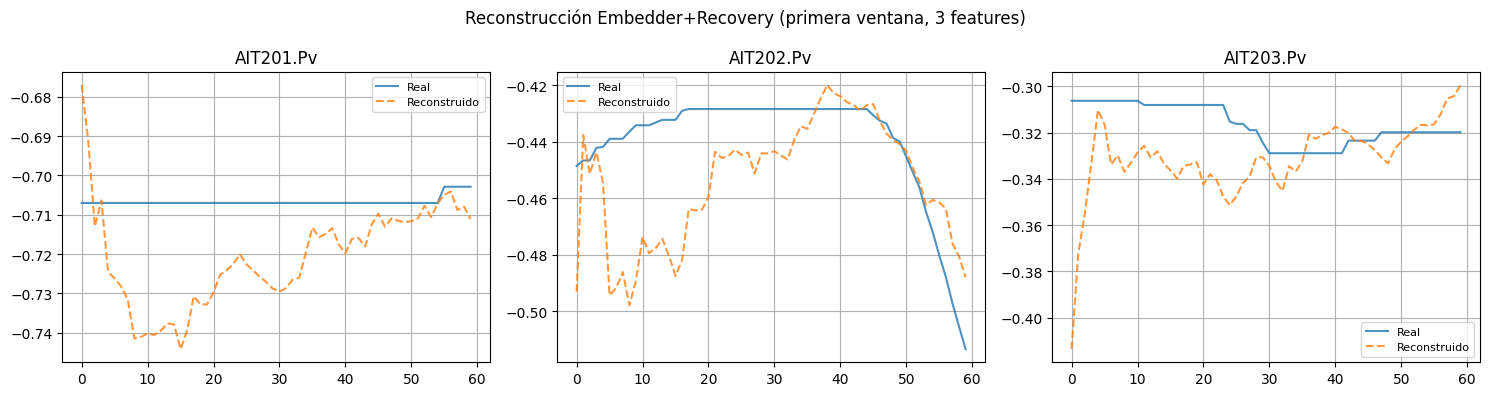

In [21]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()

        h       = embedder(x)
        x_tilde = recovery(h)

        # MSE directo — sin 10*sqrt porque ahora los datos están en z-score
        # y la escala es diferente. Se usa MSE puro para mayor estabilidad.
        e_loss = mse_loss(x_tilde, x)

        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()
        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {epoch_loss:.6f}")

final_e = embedder_history[-1]
print(f"\nMSE final: {final_e:.6f}")
if final_e < 0.005:
    print("✅  Excelente — el embedder está capturando la estructura correctamente.")
elif final_e < 0.02:
    print("✅  Bueno — el fix funcionó. Puedes continuar.")
elif final_e < 0.05:
    print("⚠️  Aceptable pero mejorable. Considera 200 épocas más.")
else:
    print("❌  Sigue sin converger. Verifica que Recovery no tenga Sigmoid.")

# Verificar reconstrucción visual en un batch
with torch.no_grad():
    x_sample = train_tensor[:128].to(device)
    h_sample  = embedder(x_sample)
    x_rec     = recovery(h_sample).cpu().numpy()
    x_orig    = x_sample.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in enumerate(axes):
    ax.plot(x_orig[0, :, idx], label="Real", alpha=0.8)
    ax.plot(x_rec[0, :, idx],  label="Reconstruido", alpha=0.8, linestyle="--")
    ax.set_title(f"{continuous_cols[idx]}")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Reconstrucción Embedder+Recovery (primera ventana, 3 features)")
plt.tight_layout()
plt.show()


## Fase 2: Supervisor


In [22]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)

        h_sup  = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_sup[:, :-1, :])
        s_loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), max_norm=1.0)
        s_optimizer.step()
        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.002060
[Supervisor] Epoch 200/300 | Loss: 0.001827
[Supervisor] Epoch 300/300 | Loss: 0.001740


## Fase 3: Entrenamiento conjunto

**Señales de convergencia esperadas en v4:**
- Épocas 1–100: G loss alto (~2–3), D loss también alto. El generador empieza a aprender.
- Épocas 100–300: G loss debe bajar hacia ~1.5. D loss sube hacia ~1.5 (equilibrio).
- Épocas 300+: G y D oscilan en ~1.0–1.8. Eso es el equilibrio de Nash en BCE.

Si G loss se estanca en >2.5 durante muchas épocas → discriminador demasiado fuerte,
sube el umbral de entrenamiento del discriminador de 0.05 a 0.15–0.3.


In [23]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch, d_epoch, e_epoch = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        # H real calculado una sola vez, sin gradiente hacia embedder
        with torch.no_grad():
            h_real = embedder(x)

        # --- Generator + Supervisor (2 pasos) ---
        for _ in range(2):
            g_optimizer.zero_grad()

            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            y_fake   = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u   = bce_loss(y_fake,   torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            h_sup    = supervisor(h_real)
            g_loss_s = mse_loss(h_real[:, 1:, :], h_sup[:, :-1, :])

            # FIX v4: eta=0.1 — la adversarial domina completamente
            g_loss = g_loss_u + gamma * g_loss_u_e + eta * g_loss_s

            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), max_norm=1.0
            )
            g_optimizer.step()

        # --- Embedder refinement (una vez) ---
        e_optimizer.zero_grad()

        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        g_s_ref = mse_loss(h_ref[:, 1:, :], h_sup_r[:, :-1, :])

        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * g_s_ref

        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()

        # --- Discriminator ---
        d_optimizer.zero_grad()

        with torch.no_grad():
            z2     = random_z(bs, seq_len, latent_dim, device)
            e_hat2 = generator(z2)
            h_hat2 = supervisor(e_hat2)

        y_real   = discriminator(h_real)
        y_fake2  = discriminator(h_hat2)
        y_fake_e2 = discriminator(e_hat2)

        d_loss = (
            bce_loss(y_real,    torch.ones_like(y_real)) +
            bce_loss(y_fake2,   torch.zeros_like(y_fake2)) +
            gamma * bce_loss(y_fake_e2, torch.zeros_like(y_fake_e2))
        )

        if d_loss.item() > 0.05:
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            d_optimizer.step()

        g_epoch += g_loss.item()
        d_epoch += d_loss.item()
        e_epoch += e_loss.item()

    g_epoch /= len(train_loader)
    d_epoch /= len(train_loader)
    e_epoch /= len(train_loader)

    joint_g_history.append(g_epoch)
    joint_d_history.append(d_epoch)
    joint_e_history.append(e_epoch)

    if (epoch + 1) % 100 == 0:
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} "
            f"| G: {g_epoch:.4f} | D: {d_epoch:.4f} | E: {e_epoch:.6f}"
        )


[Joint] Epoch 100/1000 | G: 2.1948 | D: 1.9097 | E: 0.013055
[Joint] Epoch 200/1000 | G: 2.1912 | D: 1.9140 | E: 0.004422
[Joint] Epoch 300/1000 | G: 2.2014 | D: 1.9148 | E: 0.008222
[Joint] Epoch 400/1000 | G: 2.2343 | D: 1.8733 | E: 0.004049
[Joint] Epoch 500/1000 | G: 2.1943 | D: 1.9056 | E: 0.016230
[Joint] Epoch 600/1000 | G: 2.1921 | D: 1.9122 | E: 0.005338
[Joint] Epoch 700/1000 | G: 2.7945 | D: 1.8158 | E: 0.008552
[Joint] Epoch 800/1000 | G: 2.1458 | D: 1.9235 | E: 0.007253
[Joint] Epoch 900/1000 | G: 2.6468 | D: 1.7056 | E: 0.007001
[Joint] Epoch 1000/1000 | G: 2.1665 | D: 1.9197 | E: 0.006755


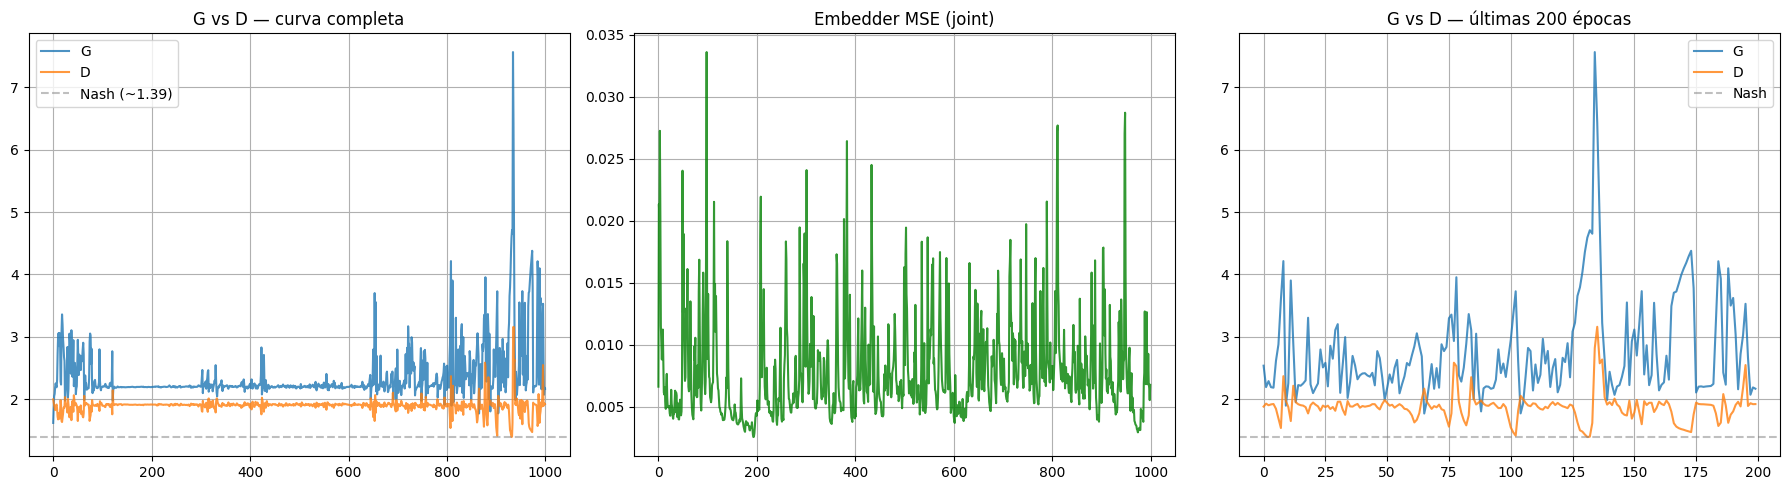

G final: 2.1665 | D final: 1.9197
Nash esperado: ~1.386
✅  Balance adversarial alcanzado


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=1.386, color='gray', linestyle='--', alpha=0.5, label="Nash (~1.39)")
axes[0].set_title("G vs D — curva completa")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (joint)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-200:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-200:], label="D", alpha=0.8)
axes[2].axhline(y=1.386, color='gray', linestyle='--', alpha=0.5, label="Nash")
axes[2].set_title("G vs D — últimas 200 épocas")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
print(f"G final: {g_f:.4f} | D final: {d_f:.4f}")
print(f"Nash esperado: ~1.386")

if 0.8 < g_f < 2.2 and 0.8 < d_f < 2.2:
    print("✅  Balance adversarial alcanzado")
elif d_f < 0.3:
    print("⚠️  Discriminador dominante — sube el umbral de d_loss a 0.2")
elif g_f > 2.5:
    print("⚠️  Generador aún colapsado — revisa la curva de embedder")


## Generación y evaluación


In [25]:
n_synth = len(train_cont_windows)
synth_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_list.append(x_hat)

synthetic_cont_zscored = np.concatenate(synth_list, axis=0)

print(f"Synthetic: {synthetic_cont_zscored.shape}")
print(f"Rango: [{synthetic_cont_zscored.min():.3f}, {synthetic_cont_zscored.max():.3f}]")
print(f"Media: {synthetic_cont_zscored.mean():.4f} | Std: {synthetic_cont_zscored.std():.4f}")

# El rango sintético debe ser parecido al real
real_mean = train_cont_windows.mean()
synth_mean = synthetic_cont_zscored.mean()
print(f"\nDiferencia de medias global: {abs(real_mean - synth_mean):.4f}")
if abs(real_mean - synth_mean) < 0.1:
    print("✅  Medias similares — el generador está en la región correcta")
else:
    print("⚠️  Medias distintas — puede indicar modo parcialmente colapsado")


Synthetic: (3784, 60, 23)
Rango: [-2.189, 1.973]
Media: -0.4165 | Std: 0.8337

Diferencia de medias global: 0.4146
⚠️  Medias distintas — puede indicar modo parcialmente colapsado


In [26]:
n_cont = len(continuous_cols)

# Sintéticas: desescalar de z-score a escala física
synth_flat         = synthetic_cont_zscored.reshape(-1, n_cont)
synth_physical     = scaler_cont_timegan.inverse_transform(synth_flat).reshape(synthetic_cont_zscored.shape)

# Re-escalar con el scaler del detector
synth_phys_flat        = synth_physical.reshape(-1, n_cont)
synth_for_detector     = scaler_cont_detector.transform(synth_phys_flat).reshape(synthetic_cont_zscored.shape)

print("Physical:", synth_physical.shape)
print("For detector:", synth_for_detector.shape)


Physical: (3784, 60, 23)
For detector: (3784, 60, 23)


c:\Users\j.manriquec\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [27]:
# Síntesis empírica de discretas (igual que v3)
def synthesize_discrete_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = []
    for _ in range(n_windows):
        window = np.zeros((window_size, len(discrete_cols)), dtype=np.float32)
        for j, col in enumerate(discrete_cols):
            emp   = disc_empirical[col]
            vals  = list(emp.keys())
            probs = list(emp.values())
            window[0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                window[t, j] = window[t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
        windows.append(window)
    return np.array(windows, dtype=np.float32)

synthetic_disc_raw = synthesize_discrete_windows(
    n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, seed=SEED
)
print("Synthetic disc raw:", synthetic_disc_raw.shape)


Synthetic disc raw: (3784, 60, 26)


In [28]:
def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        encoded_t = []
        for j, col in enumerate(discrete_cols):
            categories = discrete_value_maps[col]
            onehot = np.zeros(len(categories), dtype=np.float32)
            value = disc_array[t, j]
            if value in categories:
                onehot[categories.index(value)] = 1.0
            encoded_t.extend(onehot)
        rows.append(encoded_t)
    return np.array(rows, dtype=np.float32)

synthetic_disc_onehot = np.array([
    one_hot_encode_discrete_sequence(synthetic_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synthetic_disc_raw.shape[0])
], dtype=np.float32)
print("Synthetic disc onehot:", synthetic_disc_onehot.shape)


Synthetic disc onehot: (3784, 60, 91)


In [29]:
def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    summary_rows = []
    for w in disc_windows_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            values = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(values).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(values[1:] != values[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(values))
            feats[f"{col}__dominance"]   = pd.Series(values).value_counts(normalize=True).iloc[0]
        summary_rows.append(feats)
    return pd.DataFrame(summary_rows)

synthetic_disc_summary = summarize_discrete_windows_from_raw(synthetic_disc_raw, discrete_cols)

X_synth_cont = np.transpose(synth_for_detector, (0, 2, 1)).astype(np.float32)
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)

print("X_synth_cont for detector:", X_synth_cont.shape)
print("X_synth_disc for detector:", X_synth_disc.shape)


X_synth_cont for detector: (3784, 23, 60)
X_synth_disc for detector: (3784, 104)


## Evaluación: PCA, t-SNE y AUC

Comparación en espacio z-score (igual escala para real y sintético).


In [30]:
n_plot = min(1000, len(train_cont_windows), len(synthetic_cont_zscored))

rng = np.random.default_rng(SEED)
real_idx  = rng.choice(len(train_cont_windows),      n_plot, replace=False)
synth_idx = rng.choice(len(synthetic_cont_zscored),  n_plot, replace=False)

real_sample  = train_cont_windows[real_idx].reshape(n_plot, -1)
synth_sample = synthetic_cont_zscored[synth_idx].reshape(n_plot, -1)

print(f"Evaluando {n_plot} muestras. Dim por muestra: {real_sample.shape[1]}")

# Estadísticas rápidas
mean_diff = np.abs(real_sample.mean(axis=0) - synth_sample.mean(axis=0)).mean()
std_diff  = np.abs(real_sample.std(axis=0)  - synth_sample.std(axis=0)).mean()
print(f"Diferencia de medias: {mean_diff:.4f} (v3 era 0.2763)")
print(f"Diferencia de stds:   {std_diff:.4f} (v3 era 0.3173)")


Evaluando 1000 muestras. Dim por muestra: 1380
Diferencia de medias: 0.7979 (v3 era 0.2763)
Diferencia de stds:   0.8446 (v3 era 0.3173)


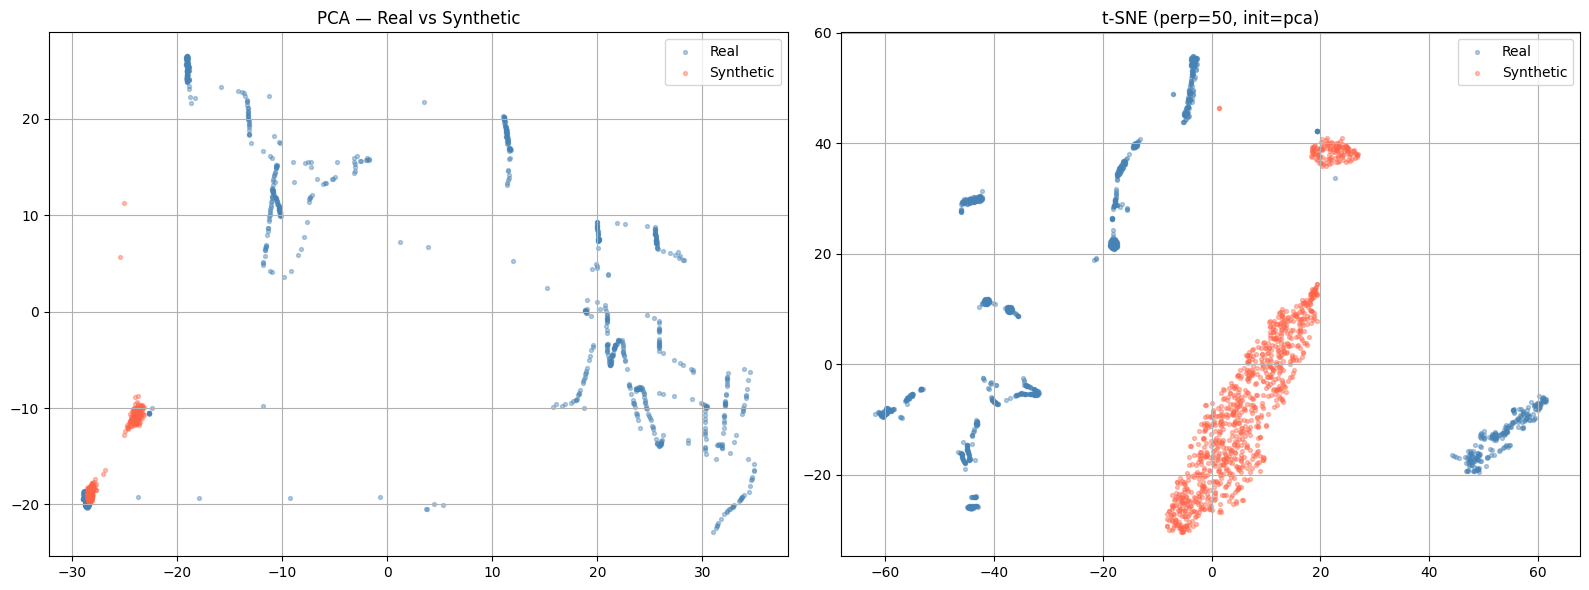

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca = PCA(n_components=2, random_state=SEED)
pca_r = pca.fit_transform(real_sample)
pca_s = pca.transform(synth_sample)

axes[0].scatter(pca_r[:, 0], pca_r[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(pca_s[:, 0], pca_s[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — Real vs Synthetic")
axes[0].legend(); axes[0].grid(True)

n_pca = min(50, real_sample.shape[1])
pca_pre = PCA(n_components=n_pca, random_state=SEED)
combined = pca_pre.fit_transform(np.vstack([real_sample, synth_sample]))

perp = min(50, n_plot // 5)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto")
tsne_out = tsne.fit_transform(combined)

axes[1].scatter(tsne_out[:n_plot, 0], tsne_out[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tsne_out[n_plot:, 0], tsne_out[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp}, init=pca)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("tsne_v4.png", dpi=150, bbox_inches="tight")
plt.show()


In [33]:
X_all = np.vstack([real_sample, synth_sample])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2,
                                           random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC discriminabilidad = {auc:.4f}")
if auc < 0.60:
    print("✅  < 0.60 — Datos sintéticos de alta calidad")
elif auc < 0.75:
    print("⚠️  0.60–0.75 — Aceptable para tesis (mejora respecto a v3=1.0)")
else:
    print("❌  > 0.75 — Revisar curvas de entrenamiento")
print("=" * 50)

# Top features con mayor diferencia
feat_names = [f"{c}_t{t}" for c in continuous_cols for t in range(WINDOW_SIZE)]
per_feat_diff = np.abs(real_sample.mean(0) - synth_sample.mean(0))
top5 = np.argsort(per_feat_diff)[-5:][::-1]
print("\nTop 5 features con mayor diferencia de media:")
for i in top5:
    col_idx = i // WINDOW_SIZE
    t_idx   = i % WINDOW_SIZE
    print(f"  {continuous_cols[col_idx]} t={t_idx}: {per_feat_diff[i]:.4f}")


AUC discriminabilidad = 1.0000
❌  > 0.75 — Revisar curvas de entrenamiento

Top 5 features con mayor diferencia de media:
  AIT202.Pv t=7: 1.8123
  AIT202.Pv t=30: 1.8082
  AIT202.Pv t=53: 1.7968
  AIT203.Pv t=16: 1.7899
  AIT203.Pv t=39: 1.7854


## Guardado


In [34]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery),
    ("generator", generator), ("supervisor", supervisor),
    ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(scaler_cont_timegan,  PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_cont_standard.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_cont_detector.pkl")

with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k, vs in discrete_value_maps.items()}, f, indent=4)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()} for k,v in disc_empirical.items()}, f, indent=4)

config = {
    "version": "v4",
    "key_fix": "Recovery sin Sigmoid + StandardScaler para TimeGAN",
    "continuous_cols": continuous_cols, "discrete_cols": discrete_cols,
    "feature_cols": feature_cols, "window_size": WINDOW_SIZE,
    "stride_detector": STRIDE_DETECTOR, "stride_timegan": TIMEGAN_STRIDE,
    "warmup": WARMUP, "seed": SEED, "feature_dim_timegan": feature_dim,
    "discrete_synthesis": "empirical_sampling_persistence_0.95",
    "hidden_dim": hidden_dim, "latent_dim": latent_dim, "num_layers": num_layers,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta, "lambda_r": lambda_r, "lambda_s": lambda_s, "lambda_m": lambda_m,
    "scaler_timegan": "StandardScaler", "scaler_detector": "StandardScaler",
    "recovery_output_activation": "None (linear)",
    "train_windows": len(train_cont_windows),
    "auc_discriminability": float(auc),
    "embedder_mse_final": float(embedder_history[-1]),
    "g_loss_final": float(joint_g_history[-1]),
    "d_loss_final": float(joint_d_history[-1]),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_zscored.npy",   synthetic_cont_zscored)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_physical.npy",  synth_physical)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_detector.npy",  synth_for_detector)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_raw.npy",       synthetic_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_onehot.npy",    synthetic_disc_onehot)
synthetic_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synthetic_disc_summary.csv", index=False)

pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Todo guardado en:", TIMEGAN_MODEL_DIR.resolve())


✅  Todo guardado en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
